# Experiment 7: Artificial Neural Network (ANN) with Keras/TensorFlow

This notebook demonstrates a complete ANN workflow with proper visualization and interpretation:
- Data loading
- Preprocessing
- ANN model design
- Training and validation
- Evaluation and confusion matrix
- Prediction illustrations

## 1. Import Libraries

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Load Dataset (Fashion-MNIST)

In [3]:
# Fashion-MNIST: 28x28 grayscale images, 10 classes
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Train full shape:', X_train_full.shape, y_train_full.shape)
print('Test shape      :', X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 14us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 57s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Train full shape: (60000, 28, 28) (60000,)
Test shape      : (10000, 28, 28) (10000,)


## 3. Initial Visualization

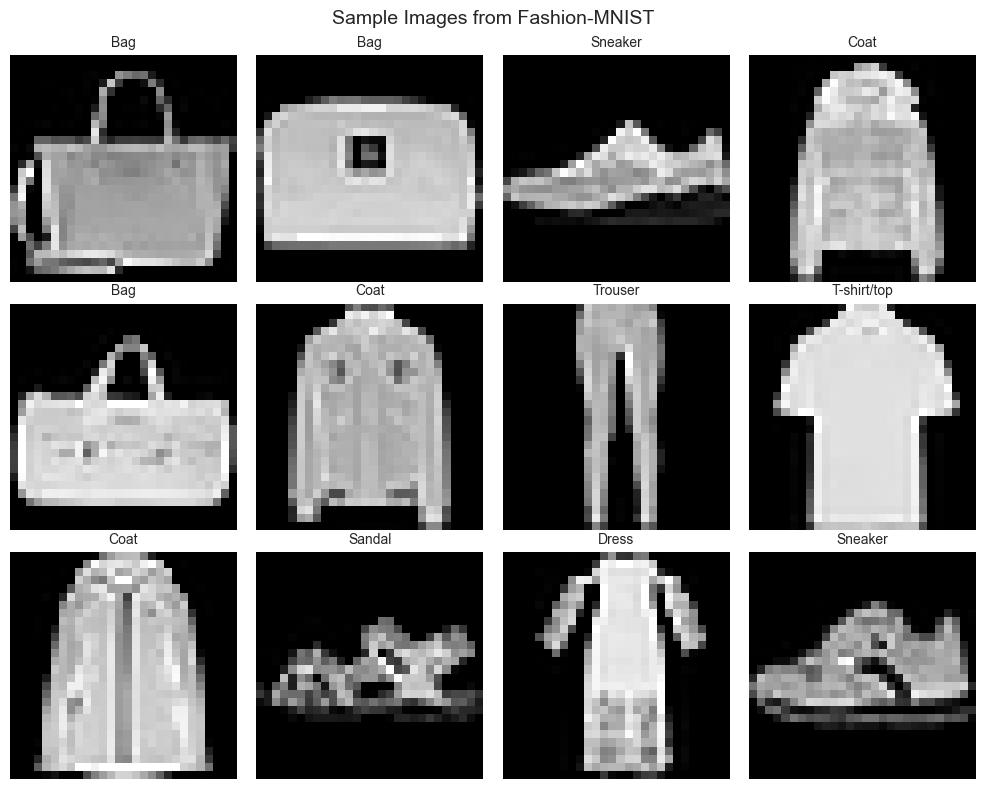

In [4]:
# Visualize random training samples
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()
idxs = np.random.choice(len(X_train_full), size=12, replace=False)

for i, idx in enumerate(idxs):
    axes[i].imshow(X_train_full[idx], cmap='gray')
    axes[i].set_title(class_names[y_train_full[idx]], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Images from Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

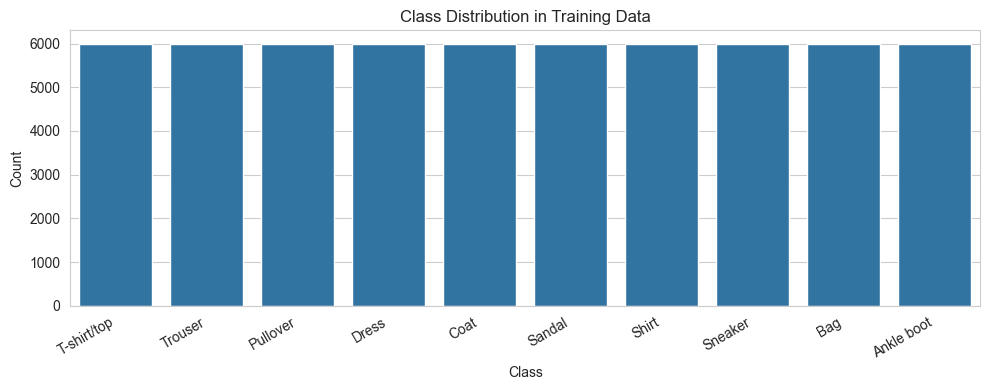

In [5]:
# Class distribution
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train_full)
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=30, ha='right')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [6]:
# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=SEED, stratify=y_train_full
)

# Flatten images for Dense ANN
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print('Train flat shape:', X_train_flat.shape)
print('Val flat shape  :', X_val_flat.shape)
print('Test flat shape :', X_test_flat.shape)

Train flat shape: (54000, 784)
Val flat shape  : (6000, 784)
Test flat shape : (10000, 784)


## 5. Build ANN Model

In [7]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

In [8]:
# Optional architecture illustration (works if graph dependencies are installed)
try:
    keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=80)
except Exception as e:
    print('plot_model could not render. This is optional.')
    print('Reason:', str(e))

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 6. Train Model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7908 - loss: 0.5843 - val_accuracy: 0.8508 - val_loss: 0.4048 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8401 - loss: 0.4359 - val_accuracy: 0.8712 - val_loss: 0.3548 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8510 - loss: 0.4051 - val_accuracy: 0.8595 - val_loss: 0.3808 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8591 - loss: 0.3863 - val_accuracy: 0.8655 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8634 - loss: 0.3676 - val_accuracy: 0.8810 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8684 - loss: 0.3539 - val_accuracy: 0.8793 - val_loss: 0.3275 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8711 - loss: 0.3476 - 

## 7. Training Curves (Visualization)

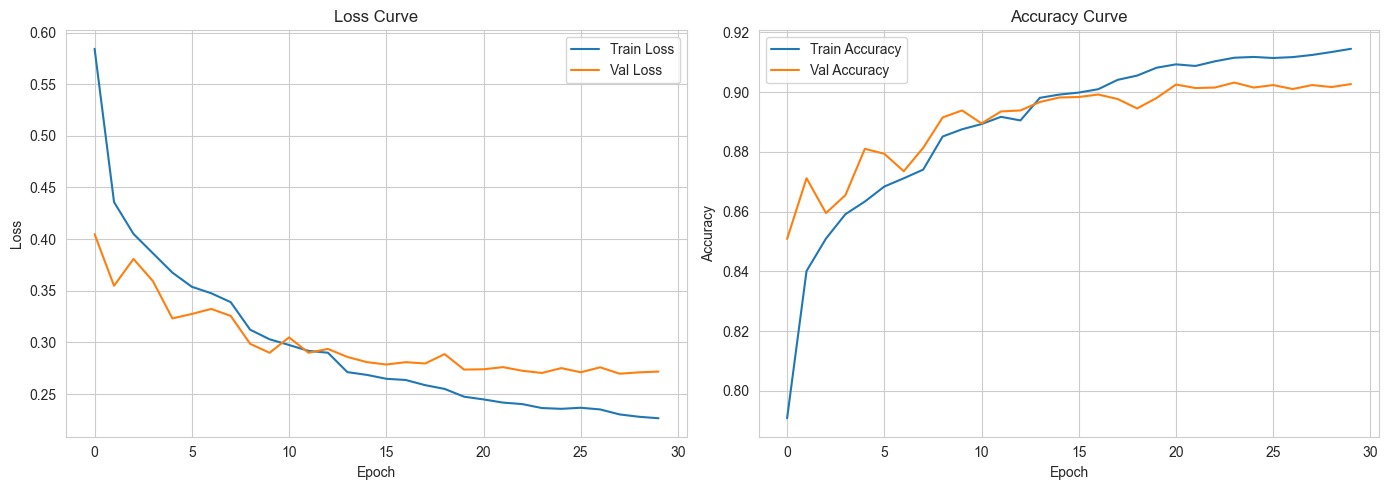

In [12]:
import pandas as pd
hist = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hist['loss'], label='Train Loss')
ax[0].plot(hist['val_loss'], label='Val Loss')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(hist['accuracy'], label='Train Accuracy')
ax[1].plot(hist['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Data

In [13]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss    : 0.3084
Test Accuracy: 0.8905


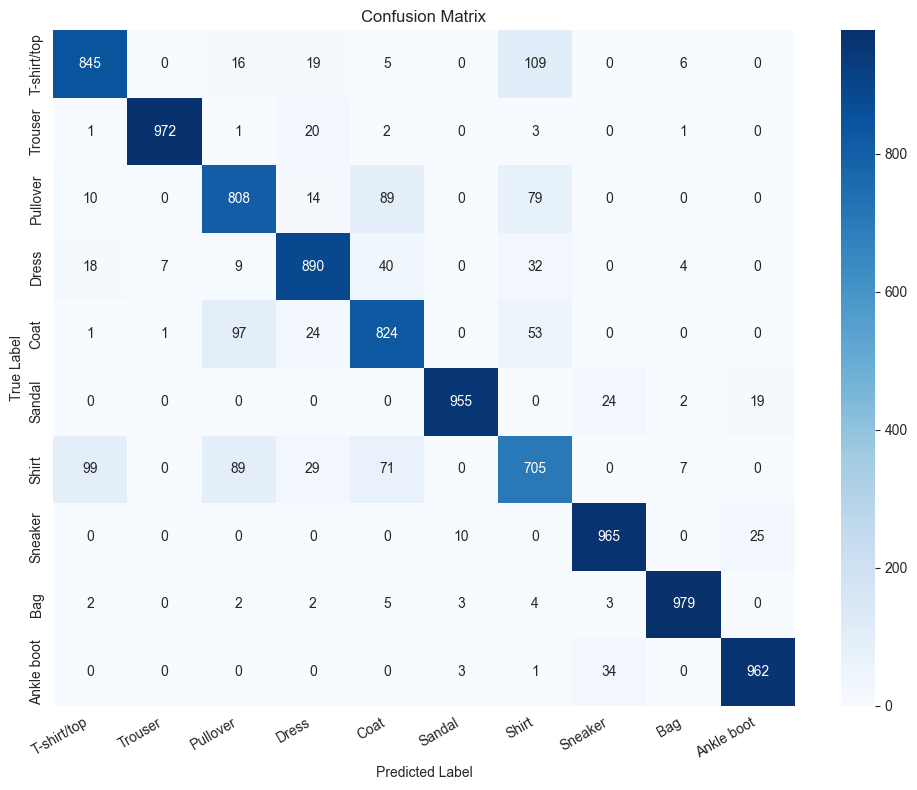

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.84      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.81      0.80      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.72      0.70      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [14]:
# Predictions and confusion matrix
y_proba = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

## 9. Prediction Illustration

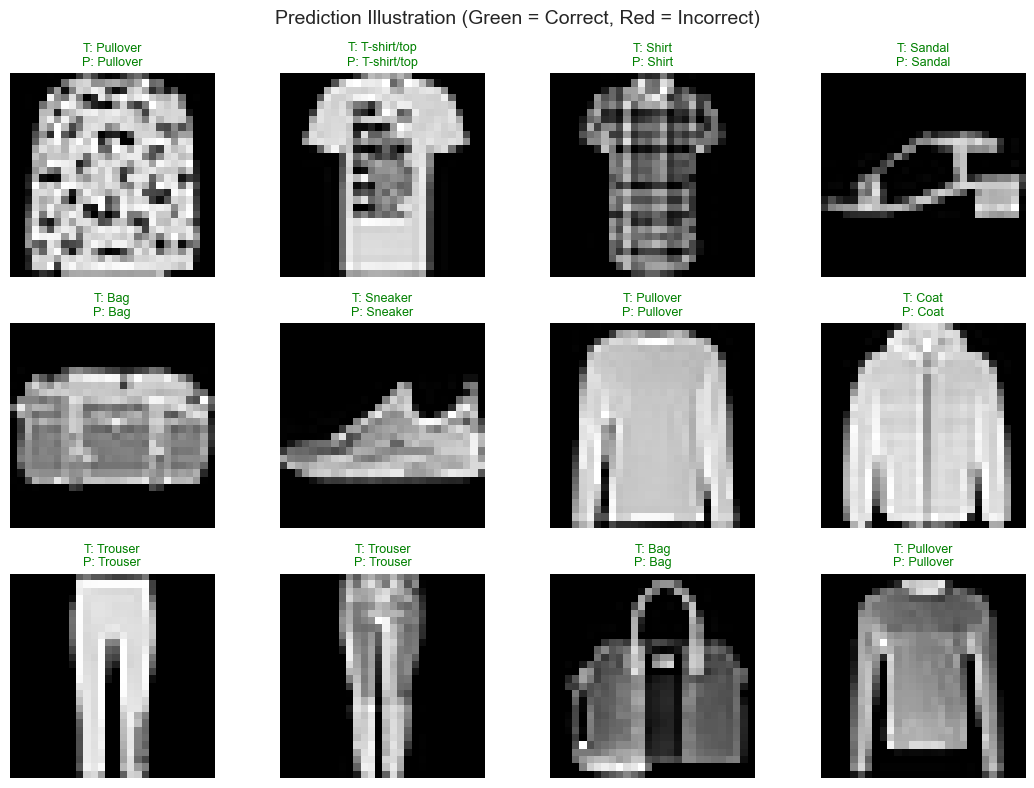

In [15]:
# Show predictions on random test images
sample_idx = np.random.choice(len(X_test), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    axes[i].imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'T: {class_names[true_label]}\nP: {class_names[pred_label]}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Prediction Illustration (Green = Correct, Red = Incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Conclusion

You have built and evaluated a complete ANN pipeline using Keras/TensorFlow with proper preprocessing, training curves, confusion matrix, and sample prediction illustrations.

If you want, this same pipeline can be adapted to your own dataset by:
1. Loading your dataset
2. Splitting features and labels
3. Normalizing/scaling features
4. Changing input shape and output classes in the model